# Exploratory Data Analysis (EDA) and Preprocessing

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
# Root path setup
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
# dataset loading
data_path_raw = PROJECT_ROOT / "dataset/raw/UNSW_NB15_training-set.csv"

df = pd.read_csv(data_path_raw)
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 1. Dataset Overview

In [3]:
print(f"Shape of the dataset: {df.shape}")
print(f"Number of unique labels: {df['label'].nunique()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Shape of the dataset: (175341, 45)
Number of unique labels: 2

Label distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [4]:
# Encoding categorical features using label encoder
le = LabelEncoder()

df['proto_encoded'] = le.fit_transform(df['proto'])
df['service_encoded'] = le.fit_transform(df['service'])
df['state_encoded'] = le.fit_transform(df['state'])

In [ ]:
features = df.columns[:-1]  # Exclude the 'label' column
print(f"Feature columns: {features}")

Text(0.5, 1.0, 'Correlation Heatmap')

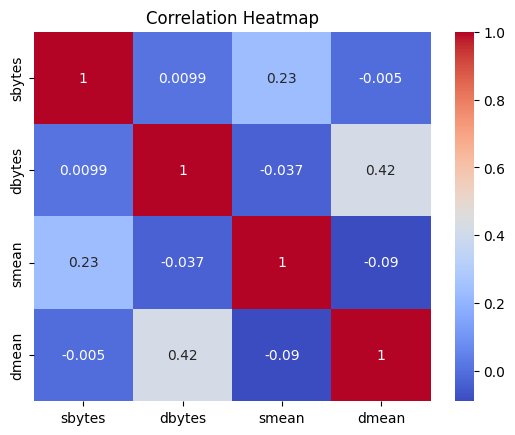

In [6]:
# Correlation heatmap
sns.heatmap(df[['sbytes','dbytes','smean','dmean']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

## 2. Feature Selection

### Volume-Based Features
- dur: Record total duration
- sbytes: Bytes sent from source
- dbytes: Bytes sent from destination
- rate: rate of traffic (intensity)

These represent traffic magnitude and may cause volume-based anomalies.

### Behavior-Based Features
- proto: Transaction protocol type (TCP, UDP, igmp, icmp,...)
- service: Application service (http, ftp, smtp,...)
- state: Connection state
- sttl / dttl: Time to Live value
- sinpkt / dinpkt: Inter-packet arrival time
- smean / dmean: Mean of packet size tranmitted

These represent how traffic behaves rather than how much traffic exists.

In [7]:
# Selecting features
selected_features = ['dur','sbytes','dbytes','rate','sttl','dttl','sinpkt','dinpkt','smean','dmean','proto_encoded','service_encoded','state_encoded','label']

df_processed = df[selected_features]
df_processed.head()

,dur,sbytes,dbytes,rate,sttl,dttl,sinpkt,dinpkt,smean,dmean,proto_encoded,service_encoded,state_encoded,label
0,0.121478,258,172,74.087490,252,254,24.295600,8.375000,43,43,113,0,2,0
1,0.649902,734,42014,78.473372,62,252,49.915000,15.432865,52,1106,113,0,2,0
2,1.623129,364,13186,14.170161,62,252,231.875571,102.737203,46,824,113,0,2,0
3,1.681642,628,770,13.677108,62,252,152.876547,90.235726,52,64,113,3,2,0
4,0.449454,534,268,33.373826,254,252,47.750333,75.659602,53,45,113,0,2,0


In [ ]:
df_processed.describe()

In [9]:
# Ploting function for distributions
def plot_distributions(df,f1,f2):
    plt.figure(figsize=(10, 3))

    subplt = plt.subplot(1, 2, 1)
    subplt.hist(df[f1], bins=50)
    subplt.set_title(f'Distribution of {f1}')

    subplt = plt.subplot(1, 2, 2)
    subplt.hist(df[f2], bins=50)
    subplt.set_title(f'Distribution of {f2}')

    plt.show()

## 3. log transformation

In [10]:
# Using log transformation to handle skewness
for col in ['dur','rate','sbytes','dbytes','smean','dmean']:
    df_processed[col] = np.log1p(df_processed[col])

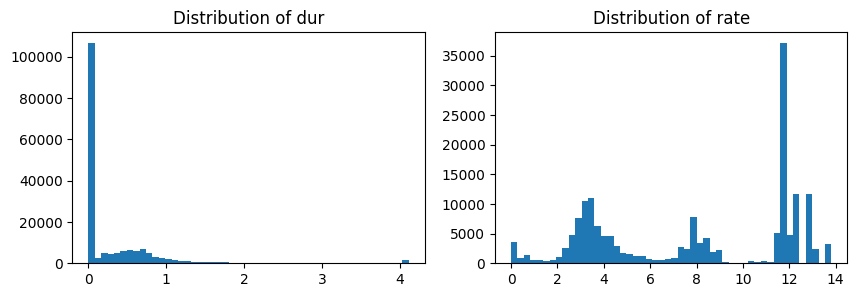

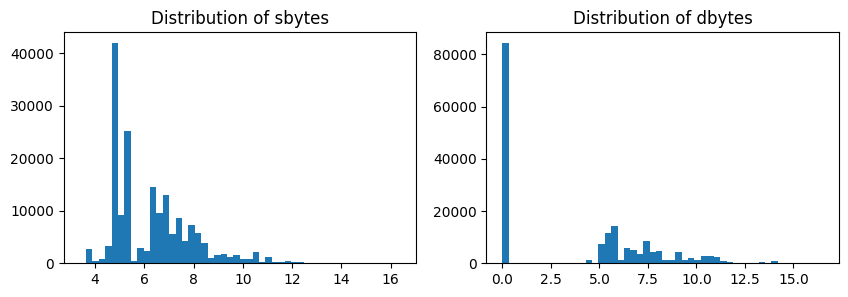

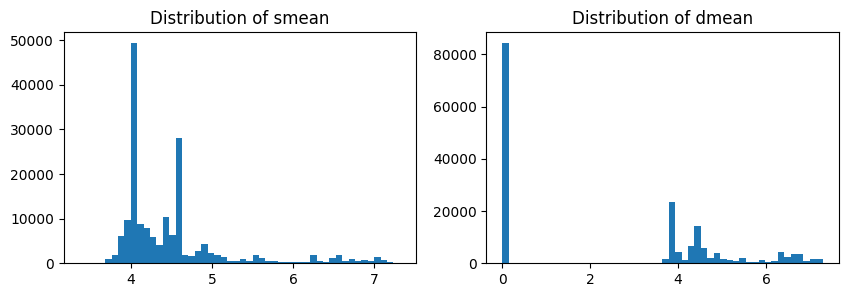

In [11]:
# Plotting distributions of lof-transformed features
plot_distributions(df_processed, 'dur', 'rate')
plot_distributions(df_processed, 'sbytes', 'dbytes')
plot_distributions(df_processed, 'smean', 'dmean')

## 4. Categorical encoding

In [12]:
# categorical feature analysis
print(f"Number of unique protocols: {df_processed['proto_encoded'].nunique()}")
print(f"Number of unique services: {df_processed['service_encoded'].nunique()}")
print(f"Number of unique states: {df_processed['state_encoded'].nunique()}")

Number of unique protocols: 133
Number of unique services: 13
Number of unique states: 9


In [13]:
# one hot encoding for 'service' and 'state'.
df_ohe = df_processed.copy()
df_ohe = pd.get_dummies(df_ohe, columns=['service_encoded', 'state_encoded'], drop_first=False)

print(f"Shape of the processed dataset: {df_ohe.shape}")

Shape of the processed dataset: (175341, 34)


## 5. Window-based aggregation
#### Since, no timestamps are given, we will aggrgate the row
#### Aggregate window_size flow (rows) into a single window
- Reduces noise
- Smooths natural fluctuations
- Highlights behavioral shifts

In [14]:
# Aggregation dictionary for windowing
agg_dict = {}

# Continuous features
continuous_cols = [
    'dur','sbytes','dbytes','rate','smean',
    'dmean','sinpkt','dinpkt','sttl','dttl'
]

for col in continuous_cols:
    agg_dict[col] = ['mean','std']

# One-hot features
one_hot_cols = [col for col in df_ohe.columns if col.startswith('service_') or col.startswith('state_')]

for col in one_hot_cols:
    agg_dict[col] = 'mean'

# Protocol diversity
agg_dict['proto_encoded'] = 'nunique'

# Label aggregation
agg_dict['label'] = 'max'

In [15]:
# Creating windows and applying aggregation
window_size = 100
df_ohe['window_id'] = df_ohe.index // window_size

df_windowed = df_ohe.groupby('window_id').agg(agg_dict)
df_windowed.columns = ['_'.join(col).strip() for col in df_windowed.columns]

# renaming the label column to window_attack
df_windowed = df_windowed.rename(columns={'label_max': 'window_attack'})

df_windowed = df_windowed.reset_index()

# dropping extremely sparse features.
df_windowed.drop(columns=['state_encoded_4_mean', 'state_encoded_7_mean', 'state_encoded_8_mean'], inplace=True)

In [16]:
display(df_windowed.head())
print(f"Shape of windowed data: {df_windowed.shape}")

,window_id,dur_mean,dur_std,sbytes_mean,sbytes_std,dbytes_mean,dbytes_std,rate_mean,rate_std,smean_mean,...,service_encoded_11_mean,service_encoded_12_mean,state_encoded_0_mean,state_encoded_1_mean,state_encoded_2_mean,state_encoded_3_mean,state_encoded_5_mean,state_encoded_6_mean,proto_encoded_nunique,window_attack
0,0,0.510057,0.877194,6.571681,1.138847,4.251369,3.409974,5.920870,4.008042,4.788326,...,0.00,0.0,0.04,0.00,0.60,0.36,0.0,0.0,4,0
1,1,0.575830,1.193919,7.009990,0.916484,3.428353,4.077962,8.423115,3.942508,5.472187,...,0.00,0.0,0.08,0.01,0.36,0.55,0.0,0.0,4,0
2,2,0.541721,1.094023,6.097047,1.266632,6.447499,1.852294,6.474863,2.489866,4.463649,...,0.01,0.0,0.69,0.00,0.31,0.00,0.0,0.0,2,0
3,3,0.694598,1.113027,6.504552,1.270745,6.984390,1.912316,5.836960,2.809455,4.512077,...,0.00,0.0,0.42,0.00,0.58,0.00,0.0,0.0,2,0
4,4,1.347959,1.398000,7.218754,0.761826,7.610472,1.454399,4.008287,2.882684,4.635605,...,0.01,0.0,0.07,0.00,0.93,0.00,0.0,0.0,2,0


Shape of windowed data: (1754, 42)


In [17]:
# attack distribution in windowed data
df_windowed['window_attack'].value_counts()

window_attack
1    1275
0     479
Name: count, dtype: int64

## 6. Save Processed Windowed Dataset

In [ ]:
data_path_windowed = PROJECT_ROOT / "dataset/processed/windowed_unsw_nb15.csv" # location to save the processed dataset
df_windowed.to_csv(data_path_windowed, index=False)